In [1]:
import os
import shutil
import random
import kagglehub
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

EPOCHS = 40
BATCH_SIZE = 32
IMG_SIZE = (150, 150)
BASE_DIR = '/content/my_dataset'

## **PHẦN 1: CHUẨN BỊ VÀ CÂN BẰNG DỮ LIỆU**
Tải dataset gốc từ Kaggle. Dữ liệu thực tế thường bị mất cân bằng. Thuật toán dưới đây sẽ tự động tìm thư mục ảnh, lọc các file lỗi và chia đều số lượng ảnh cho mỗi lớp theo chuẩn: **800 Train - 200 Valid - 200 Test**

In [2]:
path = kagglehub.dataset_download("utkarshsaxenadn/fast-food-classification-dataset")

# Tìm mục chứa ảnh
true_train_path = ""
for root, dirs, files in os.walk(path):
    if "Train" in dirs and len(os.listdir(os.path.join(root, "Train"))) > 0:
        true_train_path = os.path.join(root, "Train")
        break

# Dọn mấy file cũ đã chạy
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

classes = sorted([d for d in os.listdir(true_train_path) if os.path.isdir(os.path.join(true_train_path, d))])[:10]
# Phân chia ảnh
for cls in classes:
    for split in ['Train', 'Valid', 'Test']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

    src = os.path.join(true_train_path, cls)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.seed(42)
    random.shuffle(imgs)
    # Tăng mức ảnh lên 800
    for i, f in enumerate(imgs[:800]):
        if i < 500: dest = 'Train'
        elif i < 650: dest = 'Valid'
        else: dest = 'Test'
        shutil.copy(os.path.join(src, f), os.path.join(BASE_DIR, dest, cls, f))

# Nạp vào tf.data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Train'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'Valid'), image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

Using Colab cache for faster access to the 'fast-food-classification-dataset' dataset.
Found 5000 files belonging to 10 classes.
Found 1500 files belonging to 10 classes.


 ## **PHẦN 2: MÔ HÌNH CƠ BẢN- BASELINE CNN - PHASE 1**
Xây dựng mạng CNN thuần túy, độ sâu vừa phải, KHÔNG có tính năng Tăng cường dữ liệu. Mô hình này đóng vai trò làm điểm chuẩn để chứng minh tính hiệu quả của Phase 2.

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.1502 - loss: 2.2592 - val_accuracy: 0.1980 - val_loss: 2.1709
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.2110 - loss: 2.1517 - val_accuracy: 0.1933 - val_loss: 2.1524
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.2432 - loss: 2.0900 - val_accuracy: 0.2540 - val_loss: 2.0439
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.2642 - loss: 2.0641 - val_accuracy: 0.2447 - val_loss: 2.0488
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.2800 - loss: 2.0230 - val_accuracy: 0.2920 - val_loss: 1.9563
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.2928 - loss: 1.9908 - val_accuracy: 0.3033 - val_loss: 1.9558
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.3192 - loss: 1.9572 - val_accuracy: 0.3220 - val_loss: 1.9167
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.3314 - loss: 1.9192 - val_acc

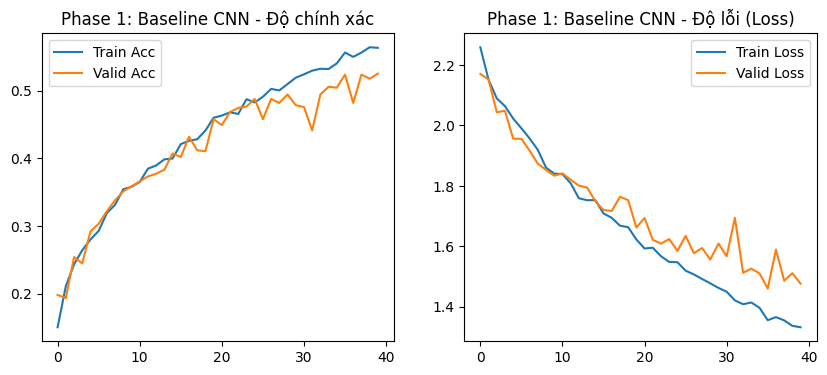

In [3]:
def build_baseline():
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),

        layers.GlobalAveragePooling2D(name="feature_layer"),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_p1 = build_baseline()
history_p1 = model_p1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# File kết quả train
model_p1.save('baseline_model_p1.keras')

# Hàm vẽ biểu đồ
def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Valid Acc')
    plt.title(f'{title} - Độ chính xác')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Valid Loss')
    plt.title(f'{title} - Độ lỗi (Loss)')
    plt.legend()
    plt.show()

plot_history(history_p1, "Phase 1: Baseline CNN")

In [4]:
feature_extractor = models.Sequential(model_p1.layers[:-1])

image_batches = []
for imgs, labs in train_ds.take(20):
    image_batches.append(imgs)
images_only = np.concatenate(image_batches, axis=0)

# Dự đoán
features = feature_extractor.predict(images_only, verbose=0)
features_cos = normalize(features)

kmeans = KMeans(n_clusters=10, random_state=42).fit(features_cos)

# Xuất file K-Means
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.0964 - loss: 2.3041 - val_accuracy: 0.0993 - val_loss: 2.2988
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.1224 - loss: 2.2852 - val_accuracy: 0.1607 - val_loss: 2.2729
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.1508 - loss: 2.2525 - val_accuracy: 0.1700 - val_loss: 2.2086
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.1752 - loss: 2.2082 - val_accuracy: 0.2293 - val_loss: 2.1094
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.2070 - loss: 2.1588 - val_accuracy: 0.2567 - val_loss: 2.0558
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.2382 - loss: 2.0926 - val_accuracy: 0.2640 - val_loss: 2.0245
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.2538 - loss: 2.0461 - val_accuracy: 0.2640 - val_loss: 2.0287
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.2702 - loss: 2.0170 - val_ac

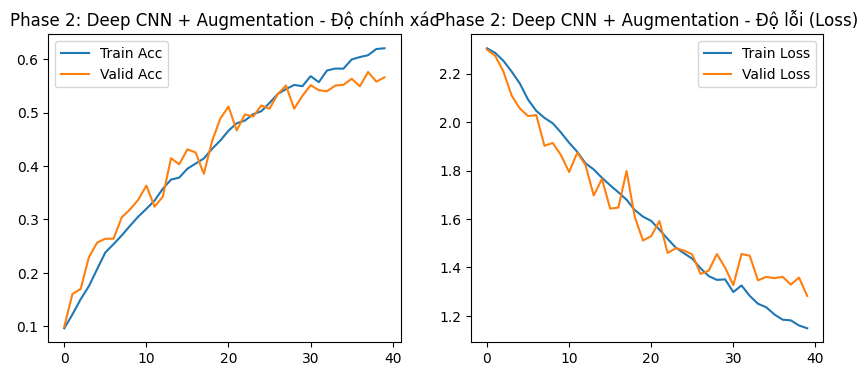

In [5]:
# 1. MODULE TĂNG CƯỜNG (DÙNG CHUNG)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="module_tang_cuong")

# 2. XÂY DỰNG DEEP CNN
model_p2 = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_p2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_p2 = model_p2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Xuất file train
model_p2.save('augmented_model_p2.keras')

plot_history(history_p2, "Phase 2: Deep CNN + Augmentation")